In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "online_retail_II.csv"

df = pd.read_csv(DATA_PATH, encoding="latin1")

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [3]:
# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# Eliminar filas vacías
df = df.dropna(how="all")

# Limpiar strings
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()

# Convertir fecha
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Convertir numéricas
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Customer ID"] = pd.to_numeric(df["Customer ID"], errors="coerce")

# Eliminar valores negativos o inválidos
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# Crear columna clave de negocio
df["TotalSales"] = df["Quantity"] * df["Price"]

print("Shape después de limpieza:", df.shape)
print(df.head())

Shape después de limpieza: (1041671, 9)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041          RECORD FRAME 7" SINGLE SIZE        48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  TotalSales  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom        83.4  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom        81.0  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom        81.0  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom       100.8  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom        30.0  


In [4]:
DB_PATH = "retail.db"
TABLE_NAME = "retail"

conn = sqlite3.connect(DB_PATH)

df.to_sql(TABLE_NAME, conn, if_exists="replace", index=False)

conn.close()

print("Base de datos creada correctamente")

Base de datos creada correctamente


In [5]:
conn = sqlite3.connect("retail.db")

query = "SELECT * FROM retail LIMIT 5;"
test_df = pd.read_sql_query(query, conn)

conn.close()

print(test_df)

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041          RECORD FRAME 7" SINGLE SIZE        48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  TotalSales  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom        83.4  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom        81.0  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom        81.0  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom       100.8  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom        30.0  


In [6]:
DB_PATH = "retail.db"

def run_query(query):
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

In [7]:
# Ingreso total generado por todas las ventas
query = """
SELECT ROUND(SUM(TotalSales), 2) AS total_revenue
FROM retail;
"""
run_query(query)

,total_revenue
0,20972968.14


In [8]:
# Top 10 Productos con más ingresos
query = """
SELECT
    Description,
    ROUND(SUM(TotalSales), 2) AS total_revenue
FROM retail
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 10;
"""
top_products = run_query(query)
top_products

,Description,total_revenue
0,REGENCY CAKESTAND 3 TIER,344563.25
1,Manual,341104.90
2,DOTCOM POSTAGE,322657.48
3,WHITE HANGING HEART T-LIGHT HOLDER,266923.55
4,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5,JUMBO BAG RED RETROSPOT,150935.56
6,PARTY BUNTING,149187.05
7,ASSORTED COLOUR BIRD ORNAMENT,132187.92
8,POSTAGE,127597.42
9,PAPER CHAIN KIT 50'S CHRISTMAS,123141.54


In [9]:
# Top 10 clientes que más gastan
query = """
SELECT
    [Customer ID] AS customer_id,
    ROUND(SUM(TotalSales), 2) AS total_spent
FROM retail
WHERE [Customer ID] IS NOT NULL
GROUP BY [Customer ID]
ORDER BY total_spent DESC
LIMIT 10;
"""
top_customers = run_query(query)
top_customers

,customer_id,total_spent
0,18102.0,608821.65
1,14646.0,528602.52
2,14156.0,313946.37
3,14911.0,295972.63
4,17450.0,246973.09
5,13694.0,196482.81
6,17511.0,175603.55
7,16446.0,168472.50
8,16684.0,147142.77
9,12415.0,144458.37


In [10]:
# Ingresos por país
query = """
SELECT
    Country,
    ROUND(SUM(TotalSales), 2) AS total_revenue
FROM retail
GROUP BY Country
ORDER BY total_revenue DESC;
"""
sales_by_country = run_query(query)
sales_by_country

,Country,total_revenue
0,United Kingdom,17871351.35
1,EIRE,664431.78
2,Netherlands,554232.34
3,Germany,431262.46
4,France,356944.60
5,Australia,169968.11
6,Spain,109178.53
7,Switzerland,101011.29
8,Sweden,91903.72
9,Denmark,69862.19


In [11]:
# Ventas mensuales
query = """
SELECT
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalSales), 2) AS monthly_revenue
FROM retail
GROUP BY month
ORDER BY month;
"""
monthly_sales = run_query(query)
monthly_sales

,month,monthly_revenue
0,2009-12,825685.76
1,2010-01,652708.50
2,2010-02,553713.31
3,2010-03,833570.13
4,2010-04,681528.99
5,2010-05,659858.86
6,2010-06,752270.14
7,2010-07,650712.94
8,2010-08,697274.91
9,2010-09,924333.01


In [12]:
# Valor promedio por compra
query = """
SELECT
    ROUND(AVG(invoice_total), 2) AS avg_ticket
FROM (
    SELECT
        Invoice,
        SUM(TotalSales) AS invoice_total
    FROM retail
    GROUP BY Invoice
);
"""
run_query(query)

,avg_ticket
0,523.3


In [13]:
# Producto más vendido por cantidad
query = """
SELECT
    Description,
    SUM(Quantity) AS total_units_sold
FROM retail
GROUP BY Description
ORDER BY total_units_sold DESC
LIMIT 10;
"""
best_sellers = run_query(query)
best_sellers

,Description,total_units_sold
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,110138
1,WHITE HANGING HEART T-LIGHT HOLDER,96683
2,ASSORTED COLOUR BIRD ORNAMENT,81809
3,"PAPER CRAFT , LITTLE BIRDIE",80995
4,JUMBO BAG RED RETROSPOT,79279
5,MEDIUM CERAMIC TOP STORAGE JAR,78033
6,BROCADE RING PURSE,71430
7,PACK OF 60 PINK PAISLEY CAKE CASES,56794
8,60 TEATIME FAIRY CAKE CASES,54716
9,SMALL POPCORN HOLDER,49948


In [14]:
# Clientes más frecuentes
query = """
SELECT
    [Customer ID] AS customer_id,
    COUNT(DISTINCT Invoice) AS num_orders
FROM retail
WHERE [Customer ID] IS NOT NULL
GROUP BY [Customer ID]
ORDER BY num_orders DESC
LIMIT 10;
"""
frequent_customers = run_query(query)
frequent_customers

,customer_id,num_orders
0,14911.0,398
1,12748.0,336
2,17841.0,211
3,15311.0,208
4,13089.0,203
5,14606.0,192
6,14156.0,156
7,17850.0,155
8,14646.0,151
9,18102.0,145


In [15]:
# Actividad comercial por país
query = """
SELECT
    Country,
    COUNT(DISTINCT Invoice) AS total_orders,
    COUNT(DISTINCT [Customer ID]) AS unique_customers,
    ROUND(SUM(TotalSales), 2) AS total_revenue,
    ROUND(AVG(TotalSales), 2) AS avg_line_sale
FROM retail
GROUP BY Country
ORDER BY total_revenue DESC;
"""
country_summary = run_query(query)
country_summary

,Country,total_orders,unique_customers,total_revenue,avg_line_sale
0,United Kingdom,36536,5350,17871351.35,18.65
1,EIRE,626,5,664431.78,38.30
2,Netherlands,228,22,554232.34,108.93
3,Germany,789,107,431262.46,25.83
4,France,622,95,356944.60,25.61
5,Australia,95,15,169968.11,93.80
6,Spain,154,41,109178.53,29.36
7,Switzerland,93,22,101011.29,32.21
8,Sweden,105,19,91903.72,68.69
9,Denmark,43,12,69862.19,87.55


In [16]:
# Clientes de alto valor y alta frecuencia
query = """
SELECT
    [Customer ID] AS customer_id,
    COUNT(DISTINCT Invoice) AS num_orders,
    ROUND(SUM(TotalSales), 2) AS total_spent
FROM retail
WHERE [Customer ID] IS NOT NULL
GROUP BY [Customer ID]
HAVING COUNT(DISTINCT Invoice) >= 5
ORDER BY total_spent DESC
LIMIT 20;
"""
high_value_customers = run_query(query)
high_value_customers

,customer_id,num_orders,total_spent
0,18102.0,145,608821.65
1,14646.0,151,528602.52
2,14156.0,156,313946.37
3,14911.0,398,295972.63
4,17450.0,51,246973.09
5,13694.0,143,196482.81
6,17511.0,60,175603.55
7,16684.0,55,147142.77
8,12415.0,28,144458.37
9,15061.0,127,137818.52


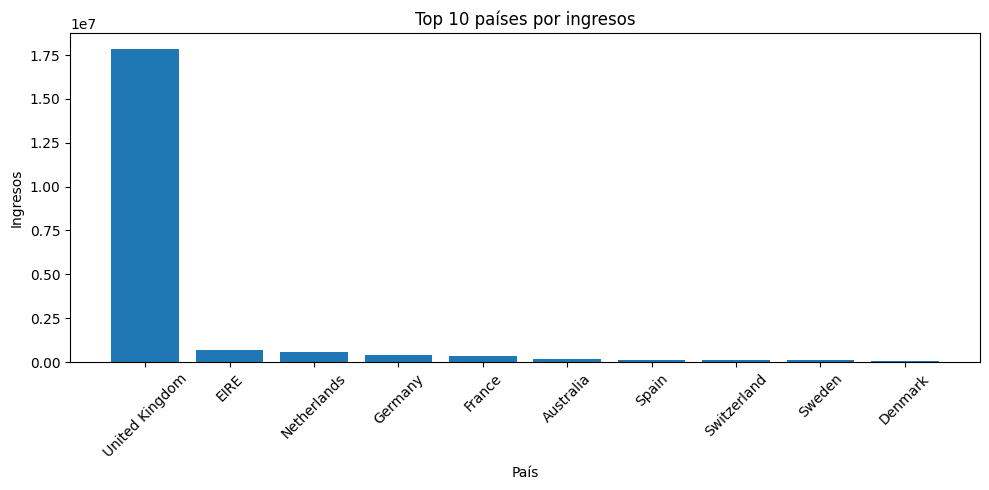

In [17]:
# Ventas por país
plt.figure(figsize=(10, 5))
plt.bar(sales_by_country["Country"].head(10), sales_by_country["total_revenue"].head(10))
plt.title("Top 10 países por ingresos")
plt.xlabel("País")
plt.ylabel("Ingresos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

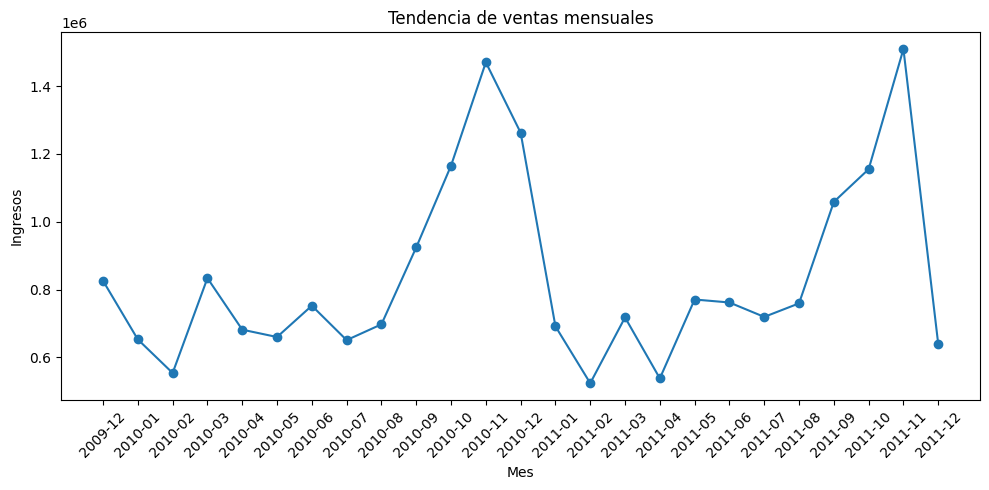

In [18]:
# Ventas mensuales
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["month"], monthly_sales["monthly_revenue"], marker="o")
plt.title("Tendencia de ventas mensuales")
plt.xlabel("Mes")
plt.ylabel("Ingresos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

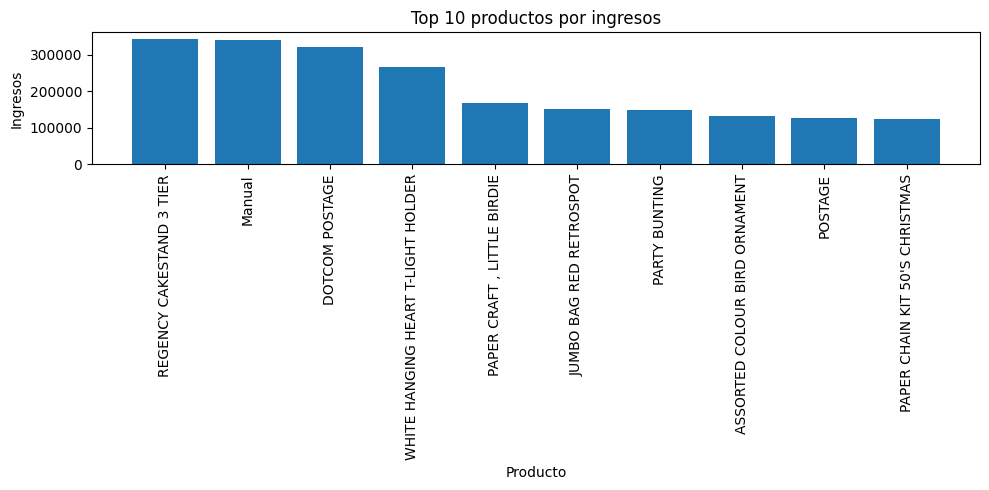

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(top_products["Description"], top_products["total_revenue"])
plt.title("Top 10 productos por ingresos")
plt.xlabel("Producto")
plt.ylabel("Ingresos")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [20]:
sales_by_country.head()
monthly_sales.head()
top_products.head()

,Description,total_revenue
0,REGENCY CAKESTAND 3 TIER,344563.25
1,Manual,341104.90
2,DOTCOM POSTAGE,322657.48
3,WHITE HANGING HEART T-LIGHT HOLDER,266923.55
4,"PAPER CRAFT , LITTLE BIRDIE",168469.60


In [21]:
query = """
SELECT
    Description,
    ROUND(SUM(TotalSales), 2) AS total_revenue
FROM retail
WHERE Description NOT IN ('Manual', 'DOTCOM POSTAGE')
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 10;
"""
clean_top_products = run_query(query)
clean_top_products

,Description,total_revenue
0,REGENCY CAKESTAND 3 TIER,344563.25
1,WHITE HANGING HEART T-LIGHT HOLDER,266923.55
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,JUMBO BAG RED RETROSPOT,150935.56
4,PARTY BUNTING,149187.05
5,ASSORTED COLOUR BIRD ORNAMENT,132187.92
6,POSTAGE,127597.42
7,PAPER CHAIN KIT 50'S CHRISTMAS,123141.54
8,CHILLI LIGHTS,85489.91
9,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
